# Direct data access examples for the GGDC project

This notebook shows a series of direct data access methods, without downloading files locally. The examples are written from scratch and do not require installing the `geodata` library itself, only major Python libraries relevant to the example. Many other programming languages and libraries support the same underlying operations.

In [1]:
## Data access handlers
from pystac_client import Client
import stackstac
import xarray as xr
import geopandas as gpd

## For ananymous authentication
import planetary_computer

## For plotting and basic computation examples
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import xdem
from rasterio.enums import Resampling

## Optional to silence a pyproj reprojection warning about loss of skew parameter
import warnings
warnings.filterwarnings('ignore')

## Copernicus DEM

### opentopgraphy VRT example

#### Load the global 30m product

In [2]:
%%time
url = 'https://opentopography.s3.sdsc.edu/raster/COP30/COP30_hh.vrt'
ds = xr.open_dataarray(url,chunks='auto')
ds

CPU times: user 422 ms, sys: 126 ms, total: 548 ms
Wall time: 3.04 s


<xarray.DataArray 'band_data' (band: 1, y: 626401, x: 1296001)> Size: 3TB
dask.array<open_dataset-band_data, shape=(1, 626401, 1296001), dtype=float32, chunksize=(1, 5760, 5761), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 10MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * y            (y) float64 5MB 84.0 84.0 84.0 84.0 ... -90.0 -90.0 -90.0 -90.0
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Point

#### Clip to Aletsch glacier bounds

In [3]:
%%time
xmin, ymin, xmax, ymax = [7.92, 46.39, 8.14, 46.58]
clipped = ds.rio.clip_box(xmin, 
                          ymin, 
                          xmax, 
                          ymax).squeeze("band", 
                                        drop=True).rename("elevation").to_dataset()
clipped["elevation"]

CPU times: user 3.53 ms, sys: 264 μs, total: 3.8 ms
Wall time: 3.58 ms


<xarray.DataArray 'elevation' (y: 685, x: 793)> Size: 2MB
dask.array<getitem, shape=(685, 793), dtype=float32, chunksize=(685, 793), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 6kB 7.92 7.92 7.921 7.921 ... 8.139 8.139 8.14 8.14
  * y            (y) float64 5kB 46.58 46.58 46.58 46.58 ... 46.39 46.39 46.39
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point

#### Plot the DEM

CPU times: user 269 ms, sys: 108 ms, total: 378 ms
Wall time: 6.4 s


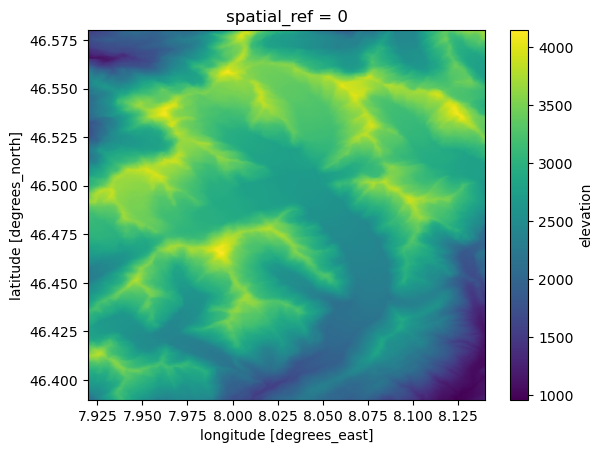

In [4]:
%%time
clipped['elevation'].plot()

#### Reproject and plot hillshade

In [5]:
# reproject
clipped = clipped.rio.reproject("EPSG:2056",resampling=Resampling.bilinear)

In [6]:
# compute hillshade
resolution = clipped.rio.resolution()[0]
hillshade = xdem.terrain.hillshade(clipped.elevation.values, resolution=resolution)
clipped['hillshade'] = (('y','x'), hillshade)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


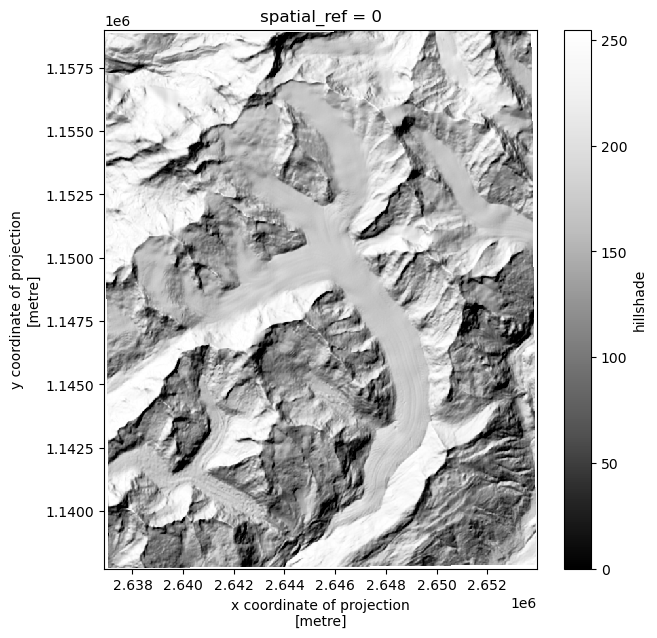

In [7]:
# plot with equal aspect
fig,ax = plt.subplots(figsize = (7,7))
clipped['hillshade'].plot(ax=ax, cmap="Greys_r")
ax.set_aspect("equal")

#### Optionally save to disk

In [8]:
# clipped['elevation'].rio.to_raster('clipped.tif')

### Microsoft Planetary Computer STAC example

In [9]:
url = "https://planetarycomputer.microsoft.com/api/stac/v1"
collection = "cop-dem-glo-30"
asset_key = 'data'
bbox = [7.92, 46.39, 8.14, 46.58]
resolution = 30
epsg = 2056

catalog = Client.open(url, modifier=planetary_computer.sign_inplace)
search = catalog.search(collections=[collection], bbox=bbox, limit=50)
items = search.item_collection()

stack = stackstac.stack(items, 
                        assets=[asset_key], 
                        epsg=epsg, 
                        bounds_latlon=bbox,
                        resolution=resolution,
                        resampling=Resampling.bilinear,)

stack = stackstac.mosaic(stack, dim="time").squeeze(drop=True).rename("elevation").to_dataset()
stack['elevation']

<xarray.DataArray 'elevation' (y: 709, x: 569)> Size: 3MB
dask.array<getitem, shape=(709, 569), dtype=float64, chunksize=(709, 569), chunktype=numpy.ndarray>
Coordinates:
  * x           (x) float64 5kB 2.637e+06 2.637e+06 ... 2.654e+06 2.654e+06
  * y           (y) float64 6kB 1.159e+06 1.159e+06 ... 1.138e+06 1.138e+06
    gsd         int64 8B 30
    proj:shape  object 8B {3600}
    proj:code   <U9 36B 'EPSG:4326'
    platform    <U8 32B 'TanDEM-X'
    epsg        int64 8B 2056
Attributes:
    spec:        RasterSpec(epsg=2056, bounds=(2636880, 1137720, 2653950, 115...
    crs:         epsg:2056
    transform:   | 30.00, 0.00, 2636880.00|\n| 0.00,-30.00, 1158990.00|\n| 0....
    resolution:  30

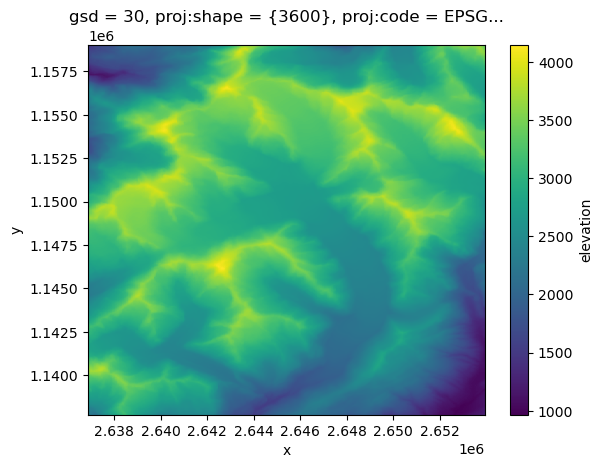

In [10]:
stack['elevation'].plot()

In [11]:
# compute hillshade
resolution = stack.rio.resolution()[0]
hillshade = xdem.terrain.hillshade(stack.elevation.values, resolution=resolution)
stack['hillshade'] = (('y','x'), hillshade)

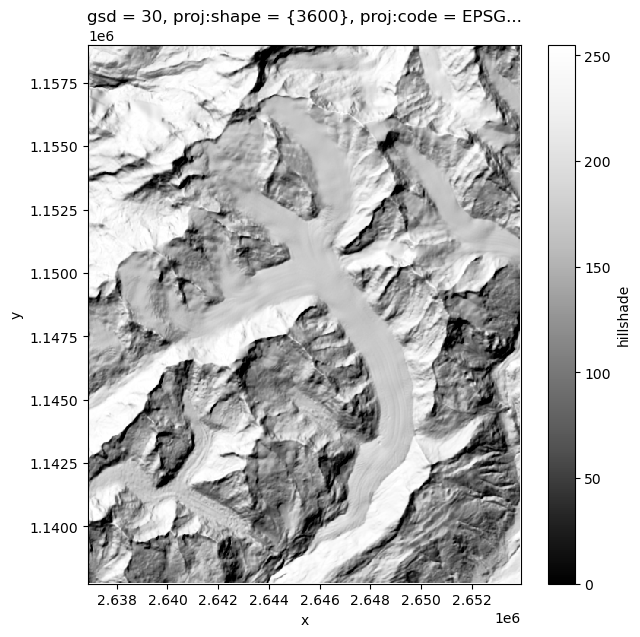

In [12]:
# plot with equal aspect
fig,ax = plt.subplots(figsize = (7,7))
stack['hillshade'].plot(ax=ax, cmap="Greys_r")
ax.set_aspect("equal")

## ESA Worldcover

In [13]:
url = 'https://planetarycomputer.microsoft.com/api/stac/v1'
collection = "esa-worldcover"
bbox = [7.92, 46.39, 8.14, 46.58]
epsg_code = 2056

catalog = Client.open(url, modifier=planetary_computer.sign_inplace)
search = catalog.search(collections=[collection],
                        bbox=bbox,
                       datetime="2021-01-01/2022-12-31",
                       )
items = search.item_collection()
stack = stackstac.stack(items, 
                        assets=["map"], 
                        epsg=epsg_code, 
                        bounds_latlon=bbox,
                        resampling=Resampling.bilinear)

stack = stack.squeeze("band", drop=True).rename("land_cover").to_dataset()
stack = stack.squeeze("time", drop=True)
stack["land_cover"]

<xarray.DataArray 'land_cover' (y: 2293, x: 2595)> Size: 48MB
dask.array<getitem, shape=(2293, 2595), dtype=float64, chunksize=(1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/18)
  * x                               (x) float64 21kB 2.637e+06 ... 2.654e+06
  * y                               (y) float64 18kB 1.159e+06 ... 1.138e+06
    description                     <U146 584B 'Discrete classification accor...
    esa_worldcover:product_tile     <U7 28B 'N45E006'
    grid:code                       <U21 84B 'ESAWORLDCOVER-N45E006'
    instruments                     object 8B {'c-sar', 'msi'}
    ...                              ...
    proj:code                       <U9 36B 'EPSG:4326'
    proj:shape                      object 8B {36000}
    proj:transform                  object 8B {0.0, 6.0, -8.333333333333333e-...
    title                           <U18 72B 'Land Cover Classes'
    raster:bands                    object 8B {'name': 'Band1', 'nodata': 0, ...
    epsg                            int64 8B 2056
Attributes:
    spec:           RasterSpec(epsg=2056, bounds=(2636893.868973331, 1137737....
    crs:            epsg:2056
    transform:      | 6.57, 0.00, 2636893.87|\n| 0.00,-9.27, 1158989.13|\n| 0...
    resolution_xy:  (6.574008234602891, 9.268057557418484)

### Reproject and plot

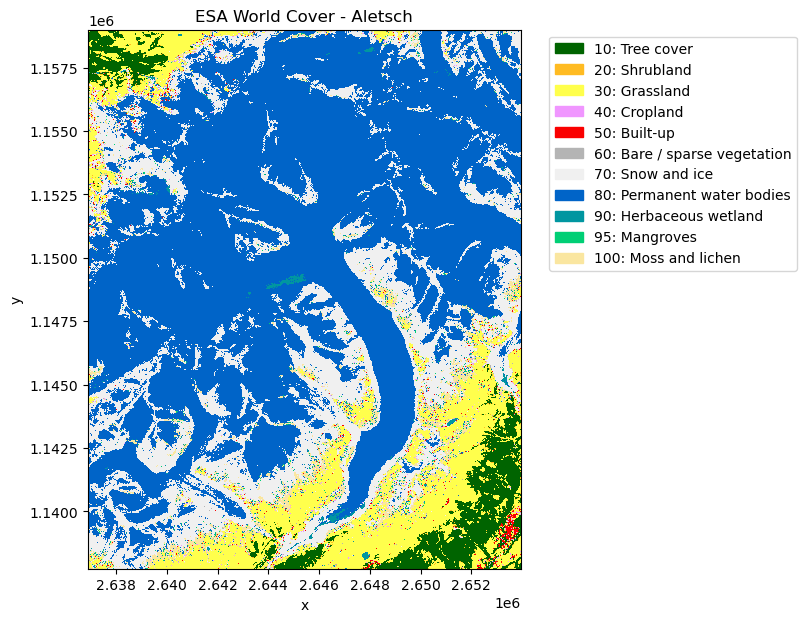

In [14]:
fig,ax = plt.subplots(figsize = (7,7))

categories = items[0].assets["map"].extra_fields["classification:classes"]
values = [cat['value'] for cat in categories]
colors = ['#' + cat['color_hint'] for cat in categories]
labels = [cat['description'] for cat in categories]
cmap = ListedColormap(colors)
legend_handles = [mpatches.Patch(color=colors[i], label=f"{values[i]}: {labels[i]}") for i in range(len(values))]

stack["land_cover"].plot(ax=ax,cmap=cmap,add_colorbar=False)
ax.axes.set_title('ESA World Cover - Aletsch')
ax.axes.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_aspect("equal")

## Global Administrative Areas vector data example
Direct read of a vector dataset

In [15]:
zip_url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_CHE_shp.zip"
file_name = "gadm41_CHE_0.shp"

In [16]:
vsi_path = f"/vsizip/vsicurl/{zip_url}/{file_name}"
gdf = gpd.read_file(vsi_path)

In [17]:
gdf.explore()